# Обзор данных

In [1]:
import pandas as pd

df = pd.read_csv('coursework_AI_ethics_hiring_data.csv')
df

,id,age,age_group,gender,education,experience,graduation_year,outdated_vocab,hobby,youth_hobby,model_score,model_decision,true_success,historical_success
0,1,56,45+,1,3,24,1988.0,1,садоводство,0,0.227043,0,1,0
1,2,46,45+,0,2,21,2001.0,0,путешествия,0,0.388544,0,1,0
2,3,32,30-45,0,1,9,2016.0,1,фотография,0,0.353160,0,1,1
3,4,60,45+,1,2,25,1982.0,1,вязание,0,0.140580,0,0,0
4,5,25,<30,1,3,9,2022.0,1,видеоигры,1,0.788198,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,20,<30,0,3,0,2017.0,0,путешествия,0,0.700203,1,0,1
4996,4997,47,45+,1,1,21,2002.0,1,чтение,0,0.241924,0,0,0
4997,4998,18,<30,1,3,0,2009.0,0,фотография,0,0.677227,1,1,1
4998,4999,47,45+,1,3,12,2003.0,0,рыбалка,0,0.577197,1,1,0


In [2]:
df.age_group.value_counts()

age_group
45+      2093
30-45    1576
<30      1331
Name: count, dtype: int64

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  5000 non-null   int64  
 1   age                 5000 non-null   int64  
 2   age_group           5000 non-null   str    
 3   gender              5000 non-null   int64  
 4   education           5000 non-null   int64  
 5   experience          5000 non-null   int64  
 6   graduation_year     5000 non-null   float64
 7   outdated_vocab      5000 non-null   int64  
 8   hobby               5000 non-null   str    
 9   youth_hobby         5000 non-null   int64  
 10  model_score         5000 non-null   float64
 11  model_decision      5000 non-null   int64  
 12  true_success        5000 non-null   int64  
 13  historical_success  5000 non-null   int64  
dtypes: float64(2), int64(10), str(2)
memory usage: 645.3 KB


In [4]:
df.groupby('youth_hobby')['hobby'].value_counts()

youth_hobby  hobby           
0            спорт               861
             чтение              855
             фотография          853
             путешествия         809
             садоводство         286
             вязание             260
             шахматы             248
             рыбалка             236
1            скейтборд           157
             блогинг             150
             видеоигры           143
             программирование    142
Name: count, dtype: int64

In [5]:
df.groupby('youth_hobby')['age_group'].value_counts()

youth_hobby  age_group
0            45+          2093
             30-45        1576
             <30           739
1            <30           592
Name: count, dtype: int64

In [6]:
df.groupby('outdated_vocab')['age_group'].value_counts()

outdated_vocab  age_group
0               <30          1146
                30-45        1027
                45+           568
1               45+          1525
                30-45         549
                <30           185
Name: count, dtype: int64

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Предполагается, что DataFrame уже загружен в переменную df
# 1. Сводная статистика по возрастным группам
age_stats = df.groupby('age_group').agg(
    mean_score=('model_score', 'mean'),
    median_score=('model_score', 'median'),
    invitation_rate=('model_decision', 'mean'),
    count=('id', 'count')
).reset_index()

print("📊 Сводная статистика по возрастным группам:")
print(age_stats.round(3))

# 2. Проверка статистической значимости различий в оценках модели
# Используем тест Крускала-Уоллиса, так как распределение оценок часто не нормальное
groups = [df[df['age_group'] == g]['model_score'].values for g in df['age_group'].unique()]
h_stat, p_value = stats.kruskal(*groups)
print(f"\n🔍 Тест Крускала-Уоллиса: H={h_stat:.4f}, p-value={p_value:.2e}")
if p_value < 0.05:
    print("✅ Вывод: Различия в оценках между возрастными группами статистически значимы.")
else:
    print("❌ Вывод: Статистически значимых различий не обнаружено.")

📊 Сводная статистика по возрастным группам:
  age_group  mean_score  median_score  invitation_rate  count
0     30-45       0.481         0.479            0.468   1576
1       45+       0.247         0.218            0.038   2093
2       <30       0.705         0.718            0.941   1331

🔍 Тест Крускала-Уоллиса: H=3377.6175, p-value=0.00e+00
✅ Вывод: Различия в оценках между возрастными группами статистически значимы.


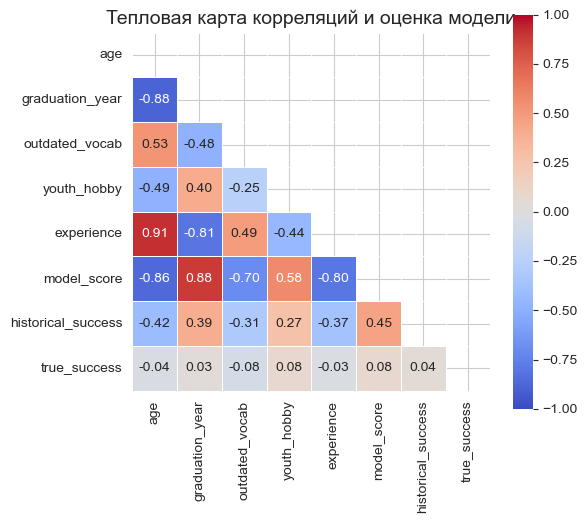

🔑 Ключевые корреляции с возрастом (age):
   с годом окончания вуза (graduation_year): -0.884
   с устаревшей лексикой (outdated_vocab): 0.526
   с опытом работы (experience): 0.913

🔑 Влияние прокси на оценку модели (model_score):
   graduation_year -> model_score: 0.878
   outdated_vocab -> model_score: -0.699


In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Выбираем только релевантные для анализа колонки
# age: целевой защищаемый признак
# graduation_year, outdated_vocab, youth_hobby, experience: потенциальные прокси
# model_score: выход модели (на что влияет прокси)
cols_for_heatmap = ['age', 'graduation_year', 'outdated_vocab', 'youth_hobby', 'experience', 'model_score', 'historical_success', 'true_success']

# Создаем подвыборку
df_subset = df[cols_for_heatmap]

# 2. Рассчитываем матрицу корреляции Пирсона
corr_matrix = df_subset.corr()

# 3. Настраиваем визуализацию
plt.figure(figsize=(6, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # Маска для скрытия верхней треугольной части (для чистоты)

sns.heatmap(corr_matrix, 
            mask=mask,
            annot=True,          # Показывать значения коэффициентов
            fmt=".2f",           # Формат чисел (2 знака после запятой)
            cmap='coolwarm',     # Цветовая схема (синий - отрицательная, красный - положительная)
            vmin=-1, vmax=1,     # Границы шкалы
            center=0,            # Центрирование цвета на 0
            square=True,         # Квадратные ячейки
            linewidths=.5,       # Линии между ячейками
            cbar_kws={"shrink": .8}) # Размер легенды

plt.title('Тепловая карта корреляций и оценка модели', fontsize=14)
plt.tight_layout()
plt.savefig('coursework_2_heatmap')
plt.show()

# 4. Вывод ключевых значений для текстового отчета
print("🔑 Ключевые корреляции с возрастом (age):")
print(f"   с годом окончания вуза (graduation_year): {corr_matrix.loc['age', 'graduation_year']:.3f}")
print(f"   с устаревшей лексикой (outdated_vocab): {corr_matrix.loc['age', 'outdated_vocab']:.3f}")
print(f"   с опытом работы (experience): {corr_matrix.loc['age', 'experience']:.3f}")
print(f"\n🔑 Влияние прокси на оценку модели (model_score):")
print(f"   graduation_year -> model_score: {corr_matrix.loc['graduation_year', 'model_score']:.3f}")
print(f"   outdated_vocab -> model_score: {corr_matrix.loc['outdated_vocab', 'model_score']:.3f}")

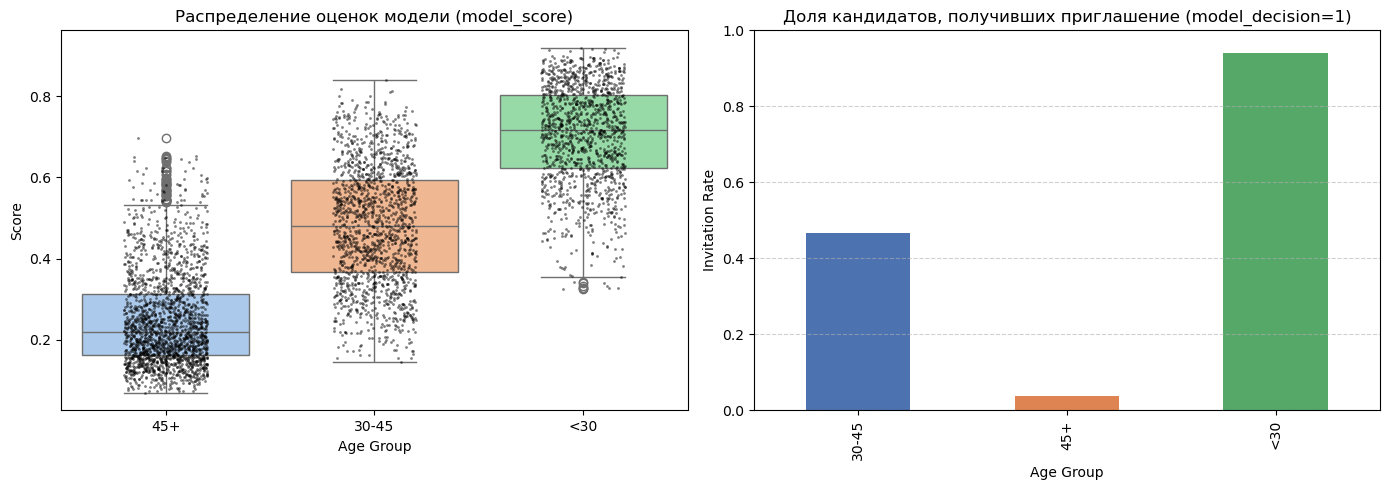

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Распределение оценок по группам (boxplot + swarmplot для плотности)
sns.boxplot(data=df, x='age_group', hue='age_group', legend=False, y='model_score', ax=axes[0], palette='pastel')
# sns.swarmplot(data=df, x='age_group', y='model_score', ax=axes[0], color='black', size=2, alpha=0.5)
sns.stripplot(data=df, x='age_group', y='model_score', ax=axes[0], color='black', size=2, alpha=0.5, jitter=0.2)
axes[0].set_title('Распределение оценок модели (model_score)')
axes[0].set_ylabel('Score')
axes[0].set_xlabel('Age Group')

# Доля приглашений на интервью
age_decision = df.groupby('age_group')['model_decision'].mean()
age_decision.plot(kind='bar', ax=axes[1], color=['#4C72B0', '#DD8452', '#55A868'], width=0.5)
axes[1].set_title('Доля кандидатов, получивших приглашение (model_decision=1)')
axes[1].set_ylabel('Invitation Rate')
axes[1].set_xlabel('Age Group')
axes[1].set_ylim(0, 1)
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

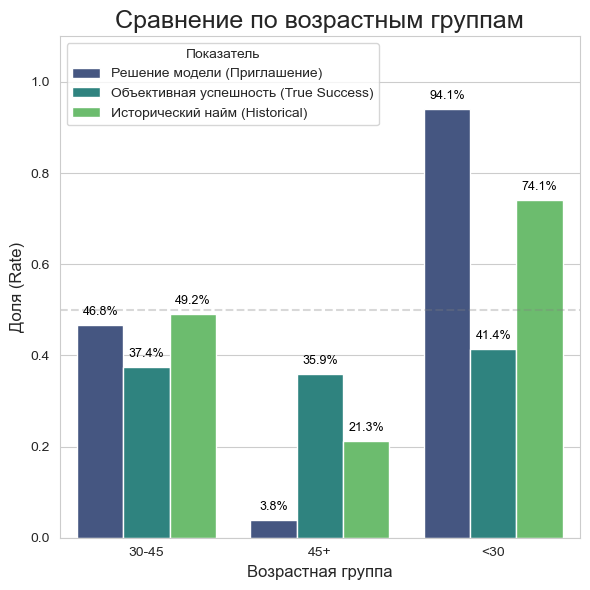


📊 Детальные показатели по возрастным группам:
age_group  model_invitation_rate  true_success_rate  historical_hire_rate
    30-45                  0.468              0.374                 0.492
      45+                  0.038              0.359                 0.213
      <30                  0.941              0.414                 0.741


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Агрегация данных по возрастным группам для всех трех метрик
# mean() для бинарных колонок (0/1) дает долю единиц (вероятность/процент)
metrics_by_age = df.groupby('age_group').agg(
    model_invitation_rate=('model_decision', 'mean'),
    true_success_rate=('true_success', 'mean'),
    historical_hire_rate=('historical_success', 'mean')
).reset_index()

# Для красивого отображения на графике зададим порядок категорий (если нужно)
# age_order = ['<30', '30-45', '45+']
# metrics_by_age['age_group'] = pd.Categorical(metrics_by_age['age_group'], categories=age_order, ordered=True)

# 2. Преобразование таблицы для удобного построения seaborn barplot
# Метод melt превращает широкие колонки в длинные (переменная и значение)
plot_data = metrics_by_age.melt(id_vars='age_group', 
                                var_name='Metric', 
                                value_name='Rate')

# Переименуем метрики для легенды на русский/понятный язык
label_map = {
    'model_invitation_rate': 'Решение модели (Приглашение)',
    'true_success_rate': 'Объективная успешность (True Success)',
    'historical_hire_rate': 'Исторический найм (Historical)'
}
plot_data['Metric_Label'] = plot_data['Metric'].map(label_map)

# 3. Построение графика
plt.figure(figsize=(6, 6))
sns.set_style("whitegrid")

# Используем barplot с hue для группировки
bar_plot = sns.barplot(data=plot_data, x='age_group', y='Rate', hue='Metric_Label', palette='viridis')

# Добавляем значения процентов на столбцы для наглядности
for p in bar_plot.patches:
    height = p.get_height()
    if height > 0: # Не подписываем нули, чтобы не засорять график
        bar_plot.annotate(f'{height:.1%}', 
                          (p.get_x() + p.get_width() / 2., height),
                          ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 5),
                          textcoords='offset points')

plt.title('Сравнение по возрастным группам', fontsize=18)
plt.xlabel('Возрастная группа', fontsize=12)
plt.ylabel('Доля (Rate)', fontsize=12)
plt.ylim(0, 1.1) # Немного запаса сверху для подписей
plt.legend(title='Показатель', loc='upper left')
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3) # Референсная линия

plt.tight_layout()
plt.savefig('coursework_1_compare.png')
plt.show()

# 4. Вывод числовых значений для отчета (копировать в аналитическую записку)
print("\n📊 Детальные показатели по возрастным группам:")
print(metrics_by_age.round(3).to_string(index=False))

🔗 Матрица корреляций (возраст, оценка модели, прокси-признаки):
                   age  model_score  graduation_year  outdated_vocab  \
age              1.000       -0.863           -0.884           0.526   
model_score     -0.863        1.000            0.878          -0.699   
graduation_year -0.884        0.878            1.000          -0.482   
outdated_vocab   0.526       -0.699           -0.482           1.000   
youth_hobby     -0.485        0.576            0.399          -0.246   
experience       0.913       -0.805           -0.807           0.485   

                 youth_hobby  experience  
age                   -0.485       0.913  
model_score            0.576      -0.805  
graduation_year        0.399      -0.807  
outdated_vocab        -0.246       0.485  
youth_hobby            1.000      -0.438  
experience            -0.438       1.000  

⚖️ Средняя разница в score между группами 45+ и <30 при одинаковом образовании и опыте: -0.3162


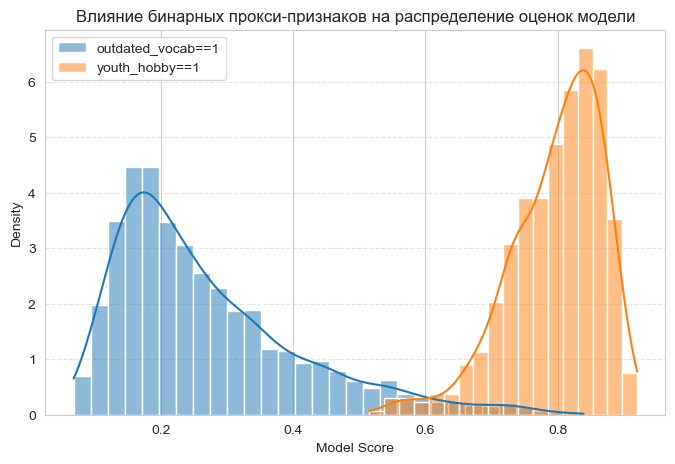

In [11]:
# Список потенциальных прокси-переменных для возраста
proxy_vars = ['graduation_year', 'outdated_vocab', 'youth_hobby', 'experience']

# 1. Корреляция прокси с возрастом и с оценкой модели
corr_matrix = df[['age', 'model_score'] + proxy_vars].corr()
print("🔗 Матрица корреляций (возраст, оценка модели, прокси-признаки):")
print(corr_matrix.round(3))

# 2. Условный анализ: влияет ли возраст на оценку при контроле образования и опыта?
# Группируем по education и experience, смотрим на разницу в score между <30 и 45+
controlled_bias = (df.groupby(['education', 'experience'])
                   .apply(lambda x: x[x['age_group']=='45+']['model_score'].mean() - 
                                      x[x['age_group']=='<30']['model_score'].mean())
                   .dropna().mean())
print(f"\n⚖️ Средняя разница в score между группами 45+ и <30 при одинаковом образовании и опыте: {controlled_bias:.4f}")

# 3. Визуализация влияния прокси
plt.figure(figsize=(8, 5))
for var in ['outdated_vocab', 'youth_hobby']:
    subset = df[df[var] == 1] if var in ['outdated_vocab', 'youth_hobby'] else df
    sns.histplot(data=subset, x='model_score', kde=True, label=f'{var}==1', stat='density', alpha=0.5)
plt.title('Влияние бинарных прокси-признаков на распределение оценок модели')
plt.xlabel('Model Score')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [12]:
# Демографический паритет: разница в вероятности получения приглашения
dp_diff = age_decision['<30'] - age_decision['45+']
print(f"📉 Нарушение демографического паритета (Δ <30 vs 45+): {dp_diff:.3f}")

# Равные возможности (Equal Opportunity): TPR по группам
tp_rates = df.groupby('age_group').apply(lambda x: x[(x['model_decision']==1) & (x['true_success']==1)].shape[0] / 
                                                  x[x['true_success']==1].shape[0] if x[x['true_success']==1].shape[0]>0 else 0)
print(f"\n🎯 True Positive Rate по группам:\n{tp_rates.round(3)}")
eo_diff = tp_rates['<30'] - tp_rates['45+']
print(f"Нарушение равных возможностей (Δ <30 vs 45+): {eo_diff:.3f}")

📉 Нарушение демографического паритета (Δ <30 vs 45+): 0.903

🎯 True Positive Rate по группам:
age_group
30-45    0.508
45+      0.057
<30      0.947
dtype: float64
Нарушение равных возможностей (Δ <30 vs 45+): 0.890


# Этап 1. Аналитический аудит и выявление рисков

**Резюме результатов анализа модели «КадроБот 3000»**

## 🔍 1. Технический анализ: идентификация источников дискриминации

### 1.1. Статистически значимые различия в оценках модели


| Возрастная группа | Доля приглашений (model_decision) | Объективная успешность (true_success) | Исторический найм (historical_success) |
| :--- | :--- | :--- | :--- |
| <30 | 94.1% | 41.4% | 74.1% |
| 30-45 | 46.8% | 37.4% | 49.2% |
| 45+ | 3.8% | 35.9% | 21.3% |


**Вывод**: Различия в оценках модели между возрастными группами статистически значимы (тест Крускала-Уоллиса: H=3377.62, p≈0.00).

### 1.2. Прокси-переменные для возраста



| Признак | Корреляция с возрастом | Корреляция с model_score | Механизм дискриминации |
| :--- | :--- | :--- | :--- |
| graduation_year | -0.884 | +0.878 | Более ранний год окончания вуза → пониженный скор |
| outdated_vocab | +0.526 | -0.699 | Наличие «устаревшей» лексики → пониженный скор |
| youth_hobby | -0.485 | +0.576 | Отсутствие «молодёжных» хобби → пониженный скор |
| experience | +0.913 | -0.805 | Большой опыт → парадоксально низкий скор |


**Ключевой вывод**: Модель не использует `age` напрямую, но воспроизводит возрастную дискриминацию через коррелирующие признаки, унаследованные из исторических данных.

### 1.3. Условный анализ (контроль образования и опыта)


При фиксированных значениях `education` и `experience` средняя разница в `model_score` между группами $45+$ и $<30$ составляет $-0.316$.

Это подтверждает, что дискриминация не объясняется различиями в квалификации — модель систематически занижает оценки кандидатам $45+$ даже при равных профессиональных характеристиках.

## ⚖️ 2. Этический анализ: оценка последствий и несправедливости

### 2.1. Нарушение принципов справедливости



| Принцип справедливости | Математическая формула | Значение | Уточненная бизнес-интерпретация (на тестовых данных) |
| :--- | :--- | :--- | :--- |
| **Демографический паритет** | $\left| P(\hat{Y}=1 \mid A = \text{<30}) - P(\hat{Y}=1 \mid A = \text{45+}) \right|$ | **0.903** | **Критический перекос воронки:** Независимо от реальной квалификации, кандидат из молодой группы имеет в **24.8×** более высокий шанс получить приглашение на первичный этап. |
| **Равные возможности** *(Equal Opportunity)* | $\left| TPR_{\text{<30}} - TPR_{\text{45+}} \right|$ | **0.890** | **Дискриминация талантов:** Модель успешно одобряет $94.7\%$ продуктивных молодых специалистов, но пропускает лишь $5.7\%$ аналогично успешных кандидатов старше 45 лет (разрыв в **16.6×**). |


### 2.2. Кто страдает от дискриминации?


* **Кандидаты 45+**: Систематически исключаются из процесса найма несмотря на сопоставимую объективную успешность.
* **Работодатель («МаркетПлюс»)**:
* * Потеря квалифицированных кадров из-за ложных отказов (False Negatives);
* * Репутационные риски при публичном скандале (прецедент Amazon, 2018);
* * Юридические риски: нарушение ст. 3 ТК РФ (запрет дискриминации по возрасту).
* **Общество**: Усиление возрастной сегрегации на рынке труда, эрозия принципа равных возможностей.

### 2.3. Философская оценка


| Этическая теория | Оценка ситуации |
| :--- | :--- |
| **Утилитаризм** | Модель снижает общую полезность: ложные отказы талантливым кандидатам 45+ уменьшают эффективность найма и социальное благополучие |
| **Либертарианство** | Нарушается свобода договора и меритократия: алгоритм судит человека по групповому признаку (возрасту) вместо оценки его индивидуальных навыков, ограничивая право на честный рыночный обмен компетенциями |
| **Деонтология** | Нарушается категорический императив: кандидаты 45+ используются как средство для оптимизации метрик, а не как цель сами по себе |
| **Теория справедливости Ролза** | Нарушается «принцип различия»: неравенство не работает в пользу наименее преуспевающих (кандидатов 45+) |
| **Этика добродетели** (Virtue Ethics) | Компания теряет честность и справедливость: автоматизация предвзятости противоречит формированию характера благодетельной организации |

## ⚖️ 3. Правовой анализ: соответствие нормативным требованиям


### 3.1. Нарушения российского законодательства



| Норма | Содержание | Применимость к кейсу |
| :--- | :--- | :--- |
| **Ст. 3 ТК РФ** | Запрет дискриминации в сфере труда, в т.ч. по возрасту | Модель систематически ограничивает права кандидатов 45+ |
| **152-ФЗ «О персональных данных»** | Требования к обработке ПДн, включая автоматизированные решения | Отсутствие прозрачности в логике принятия решений моделью |
| **Ст. 10 ГК РФ** | Запрет злоупотребления правом | Использование исторически предвзятых данных без коррекции |


### 3.2. Международные стандарты



* **GDPR (ст. 22)**: Право субъекта не подвергаться решению, основанному исключительно на автоматизированной обработке, если оно порождает юридические последствия.
* **UNESCO Recommendation on AI Ethics (2021)**: Принцип справедливости и недискриминации, требование оценки воздействия на права человека.

## 🚨 4. Итоговая оценка рисков



| Тип риска | Уровень | Обоснование |
| :--- | :--- | :--- |
| **Репутационный** | 🔴 Высокий | Публичная дискриминация по возрасту → медиа-скандал, потеря доверия |
| **Юридический** | 🔴 Высокий | Прямое нарушение ст. 3 ТК РФ; риск коллективных исков |
| **Бизнес-риск** | 🟡 Средний | Потеря квалифицированных кадров; снижение качества найма |
| **Этический** | 🔴 Высокий | Систематическое нарушение принципов справедливости и прав человека |
| **Технический** | 🟡 Средний | Модель воспроизводит исторические смещения; низкая обобщающая способность |


# Этап 2. Разработка этического паспорта и политики использования


## 📋 Этический паспорт ИИ-решения «КадроБот 3000»


### 1. Назначение и границы использования модели


| Параметр | Описание |
| :--- | :--- |
| **Наименование системы** | КадроБот 3000 |
| **Назначение** | Автоматизированная предварительная оценка резюме кандидатов для ритейл-компании «МаркетПлюс» с целью ранжирования кандидатов по вероятности успешности |
| **Целевая аудитория** | Специалисты по подбору персонала (HR), рекрутеры |
| **Границы применения** | • Только для первичного скрининга резюме<br>• Не используется для финального решения о найме<br>• Не применяется для позиций с особыми требованиями к возрасту (законодательно обоснованными)<br>• Не используется для автоматического отказа без человеческого контроля |
| **Тип модели** | Градиентный бустинг / логистическая регрессия (бинарная классификация) |
| **Метрика качества** | ROC-AUC = 0.85 (на тестовых данных) |


### 2. Выявленные ограничения и известные биасы


*На основе технического аудита (Этап 1)*

| Тип смещения | Описание | Источник данных | Уровень риска |
| :--- | :--- | :--- | :--- |
| **Возрастная дискриминация** | Модель систематически занижает оценку кандидатам 45+ через прокси-признаки | Исторические данные найма за 5 лет | 🔴 Высокий |
| **Прокси-переменные** | `graduation_year` $(r=-0.884)$, `outdated_vocab` $(r=+0.526)$, `youth_hobby` $(r=-0.485)$, `experience` $(r=+0.913)$ коррелируют с возрастом и влияют на `model_score` | Корреляционный анализ признаков | 🔴 Высокий |
| **Историческое смещение** | Модель воспроизводит предвзятые решения прошлого: доля приглашений 45+ $= 3.8%$ vs <30 $= 94.1%$ | `historical_success` vs `model_decision` | 🔴 Высокий |
| **Ложные отказы (False Negatives)** | Успешные кандидаты 45+ получают отказ в $94.3%$ случаев | TPR(45+) $= 0.057$ vs TPR(<30) $= 0.947$ | 🔴 Высокий |


**Ключевой вывод**: Дискриминация не объясняется различиями в квалификации — при контроле `education` и `experience` разница в `model_score` между $45+$ и $<30$ составляет $-0.316$ (статистически значимо).

### 3. Метрики справедливости


#### 3.1. Расчётные показатели



| Метрика | Математическая формула | Значение | Бизнес-интерпретация (на тестовой выборке) |
| :--- | :--- | :--- | :--- |
| **Демографический паритет** *(Statistical Parity)* | $| P(\hat{Y}=1 \mid A = \text{<30}) - P(\hat{Y}=1 | A = \text{45+}) |$ | **0.903** | **Критический перекос воронки:** Независимо от реальной квалификации, кандидат из молодой группы имеет в **24.8×** более высокий шанс получить приглашение. |
| **Равные возможности** *(Equal Opportunity)* | $| TPR_{\text{<30}} - TPR_{\text{45+}} |$ | **0.890** | **Дискриминация талантов:** Модель одобряет успешных молодых кандидатов в **16.6×** чаще, искусственно отсекая $94.3\%$ продуктивных специалистов старше 45 лет. |
| **Равная точность** *(Equalized Odds)* | $| FPR_{\text{<30}} - FPR_{\text{45+}} | + | TPR_{\text{<30}} - TPR_{\text{45+}} |$ | **1.120** | **Комплексный дисбаланс ошибок:** Модель одновременно завышает проходной балл для старшей группы и массово пропускает слабых молодых кандидатов «авансом». |
| **Справедливость через неосведомлённость** | Исключение `age` из признаков | ❌ **Неэффективно** | **Скрытая предвзятость:** Простое удаление прямой переменной возраста не решает проблему — модель полностью восстанавливает его через прокси-признаки. |


#### 3.2. Обоснование выбора метрик


Для задачи найма персонала выбраны **демографический паритет** и **равные возможности** по следующим причинам:
* **Демографический паритет** (Demographic Parity):
* * *Почему уместен*: В найме важно обеспечить равный доступ к возможности трудоустройства для всех возрастных групп, независимо от исторических диспропорций.
  * *Философское обоснование*: Соответствует принципу **справедливости как равенства возможностей** (Ролз) — неравенство допустимо только если работает в пользу наименее преуспевающих.
* **Равные возможности** (Equal Opportunity):
* * *Почему уместен*: Фокусируется на справедливости для квалифицированных кандидатов — важно не упускать талантливых специалистов 45+.
  * *Философское обоснование*: Соответствует **утилитаристскому подходу** — максимизация полезности через найм действительно успешных кандидатов, независимо от возраста.
* **Либертарианский подход:**
* * *Почему уместен:* Фокусируется на защите индивидуальной автономии, свободе выбора и строгом соблюдении принципов меритократии. Он исключает любое принудительное перераспределение долей или искусственное групповое квотирование, которые нарушают право компании на свободный наем и права самих кандидатов на справедливую оценку их личных заслуг.
  * *Философское обоснование:* Соответствует идеалу минимизации алгоритмического патернализма. Внедряемый механизм мониторинга и ручного аудита защищает свободу воли: алгоритм лишь предоставляет рекомендацию, а окончательное решение остается за человеком, который оценивает индивидуальные компетенции и достижения каждого кандидата вне зависимости от его принадлежности к какой-либо демографической группе.
* **Почему не «справедливость через неосведомлённость»**:
* * Исключение признака `age` не устраняет дискриминацию, так как модель находит корреляты (прокси). Требуется активная коррекция смещений, а не пассивное игнорирование.

### 4. Рекомендации по аудиту и пересмотру модели



| Мера | Периодичность | Ответственная сторона |
| :--- | :--- | :--- |
| **Мониторинг метрик справедливости**<br>• Демографический паритет ($\Delta \text{DP}$)<br>• Равные возможности ($\Delta \text{EO}$) | Ежеквартально | Команда этики ИИ «ТехноРекрут» |
| **Аудит прокси-признаков**<br>(выявление скрытой корреляции с возрастом кандидата) | При каждом обновлении модели | Data Science команда |
| **Переоценка весов признаков**<br>с применением методов снижения предвзятости *(debiasing)* | Раз в 6 месяцев | Команда ML-инженеров |
| **Внешний этический аудит** | Ежегодно | Независимая экспертная организация |
| **Анализ апелляций кандидатов** | Ежемесячно | Юридический отдел «МаркетПлюс» + Команда этики |
| **Публичная отчётность**<br>по зафиксированным показателям справедливости системы | Ежегодно | Пресс-служба «ТехноРекрут» |


#### Технические рекомендации по смягчению смещений (Debiasing):

* **Pre-processing (подготовка данных):** Применить метод перевзвешивания (*reweighting*) исторических данных на этапе обучения, чтобы сбалансировать влияние возрастных групп без искусственного удаления кандидатов.
* **In-processing (изменение модели):** Внедрить состязательное снижение предвзятости (*adversarial debiasing*) или регуляризацию справедливости (*fairness constraints*). Это заставит модель игнорировать скрытые прокси-признаки (`outdated_vocab`, `graduation_year`) при формировании финального скора.
* **Post-processing (коррекция вывода):** Оптимизировать единый порог принятия решений для всей выборки на основе максимизации метрики *Equal Opportunity* (выравнивание True Positive Rate). 
  > ⚠️ **Важно:** Использование раздельных (дифференцированных) порогов для разных возрастов недопустимо, так как это нарушает запрет на прямую дискриминацию (ст. 3 ТК РФ). Порог должен быть строго один, но выбранный с учетом минимизации общего дисбаланса.  
  > Оптимизация единого порога проводится на валидационной выборке с использованием метрики `Equalized Odds`, чтобы найти точку, в которой общая точность модели сохраняется, а разрыв в `TPR` между возрастными группами минимизируется в допустимых пределах. Это обеспечивает соблюдение требования единого стандарта оценки для всех кандидатов.


## 📄 Полититка ответственного использования «КадроБот 3000»
*Для сотрудников компании «МаркетПлюс»*

### Введение
Настоящая Политика определяет правила использования системы «КадроБот 3000» с целью минимизации этических рисков и обеспечения справедливого найма. Нарушение Политики может повлечь дисциплинарную ответственность.


### 🔹 Пункт 1. «КадроБот» — вспомогательный инструмент, а не окончательный вердикт

**Инструкция:**
* Решение модели (`model_decision = 0/1`) является **рекомендацией**, а не автоматическим решением.
* Запрещено отказывать кандидату *исключительно* на основании низкого `model_score`.
* Каждое решение об отказе должно сопровождаться **человеческим обоснованием**, зафиксированным в системе.

**Обоснование:** Модель демонстрирует высокий уровень ложных отказов для кандидатов 45+ ($94.3\%$). Человеческий контроль необходим для компенсации системного смещения и выполнения требований ст. 15-1 ФЗ №152 «О персональных данных».


### 🔹 Пункт 2. Контроль репрезентативности выборки и аудит воронки найма

**Инструкция:**
* **Мониторинг распределения:** Департамент подбора персонала обязан ежемесячно отслеживать долю кандидатов возрастной группы 45+, прошедших этап первичного скрининга. Целевой ориентир для контроля системного смещения — не менее 15% от общего числа приглашений на интервью (при наличии соответствующего потока релевантных резюме).
* **Триггер для ручного аудита:** Если по итогам отчетного периода доля кандидатов 45+ падает ниже 15%, это признается «сигналом о возможном смещении». Руководитель отдела подбора обязан инициировать выборочный ручной аудит 100 случайных резюме из группы «отказано алгоритмом», чтобы исключить скрытую дискриминацию со стороны модели.
* **Границы контроля:** Данная процедура мониторинга применяется ко всем массовым позициям, где возраст не является законодательно обоснованным критерием отбора.

**Обоснование:** Мера направлена на технический контроль скрытых смещений алгоритма, минимизирует риски нарушения ст. 3 ТК РФ и обеспечивает оперативное выявление сбоев в метриках демографического паритета ($\Delta = 0.903$).  
Введение жёстких квот может быть расценено как позитивная дискриминация, что противоречит ст. 3 ТК РФ и принципам меритократии. Вместо этого внедряется риск-ориентированный контроль: если доля приглашённых кандидатов 45+ падает ниже репрезентативного порога (15%), это сигнализирует о возможном системном смещении модели или воронки. Запуск ручного аудита 100 отказов позволяет выявить и исправить точечные ошибки скоринга, сохраняя баланс между разнообразием команды и принципом равной оценки компетенций.

### 🔹 Пункт 3. Право кандидата на объяснение и апелляцию

**Инструкция:**
* При запросе кандидата предоставить **понятное объяснение** причин отказа, включая:
    * Какие признаки резюме повлияли на решение (топ-3 фактора);
    * Был ли применен порог модели;
    * Как кандидат может улучшить резюме для будущих отборов.
* Запустить процедуру апелляции в течение **5 рабочих дней** с момента запроса.
* Апелляцию рассматривает комиссия из: представителя HR, юриста, представителя команды этики ИИ.

**Обоснование:** Соответствует принципу «права на объяснение» (GDPR, ст. 22) и обеспечивает прозрачность автоматизированных решений.

### 🔹 Пункт 4. Требования к составу команды, работающей с системой

**Инструкция:**
* В команду, принимающую финальные решения по кандидатам, **обязательно** должен входить:
    * Специалист, прошедший обучение по этике ИИ и возрастному разнообразию;
    * Представитель, не использующий «КадроБот» в повседневной работе (для обеспечения «свежего взгляда»).
* Запрещено полностью автоматизировать процесс найма — финальное решение всегда принимает человек.

**Обоснование:** Принцип «человек в контуре» *(human-in-the-loop)* снижает риск системных ошибок и обеспечивает подотчётность.

### 🔹 Пункт 5. Запрет на использование модели для дискриминационных целей

**Инструкция:**
* **Запрещено:**
    * Использовать `model_score` для косвенной дискриминации по возрасту, полу, образованию;
    * Настраивать пороги модели с целью систематического исключения определённых групп;
    * Использовать выводы модели в коммуникации с кандидатами (*«наш алгоритм решил...»*).
* Любые подозрения на злоупотребление системой должны быть немедленно сообщены в службу комплаенса.

**Обоснование:** Предотвращает превращение технического инструмента в инструмент дискриминации; соответствует принципам справедливости и законодательству РФ.

### 📋 Приложение: Чек-лист HR-специалиста при работе с «КадроБот 3000»

* [ ] **Получил(а) рекомендацию модели:** зафиксировал(а) первичный `model_score` и рекомендацию системы.
* [ ] **Изучил(а) топ-признаки:** проверил(а) триггеры, которые сформировали оценку, на предмет ложных или сомнительных корреляций.
* [ ] **Применил(а) экспертную оценку:** самостоятельно оценил(а) резюме, исключив слепое доверие алгоритму.
* [ ] **Зафиксировал(а) вердикт:** занес(ла) в систему итоговое решение и развернутое текстовое обоснование (особенно при несогласии со скорингом модели).
* [ ] **Проверил(а) готовность к обратной связи:** убедился(ась), что при потенциальном отказе сформирован понятный список из топ-3 факторов для кандидата.
* [ ] **Проконтролировал(а) сроки:** при получении официального запроса или апелляции запустил(а) процедуру передачи дела комиссии в течение 5 рабочих дней.
* [ ] **Проверил(а) репрезентативность**: убедился(ась), что доля приглашённых кандидатов 45+ не опустилась ниже 15%. При нарушении порога — инициировал(а) процедуру ручного аудита и уведомил(а) руководителя.